# Momentum without the crashes? 🛟
### Blending the momentum ETF with the min-vol ETF — a smoother ride, or just less of everything?

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

**Momentum** is the market's best-known winning streak: buy what's been going up. It works for years — and then, in a violent reversal, it *crashes* (1932, 2009). The famous fix: bolt on a **min-volatility** sleeve — the calmest stocks in the market — to soften the falls. The pitch writes itself: *momentum's returns, without momentum's crashes.*

We test the shipped version of that idea: a **50/50 blend of MTUM (momentum) and USMV (min-vol)**, rebalanced monthly, against momentum alone, min-vol alone, quality and the S&P 500 — everything measured **above cash**, net of fees, since MTUM's 2013 launch.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the bootstrap CI and the costed series? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Dedup note.** The desk already graded the momentum-*crash* mechanism ([508-momentum-crashes](../../508-momentum-crashes/)), the low-vol anomaly ([330](../../330-low-volatility-anomaly/)) and the *single* factor wrappers ([601](../../601-factor-etf-live-test/)). This study asks the **blend** question those leave open. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3b6fb0"

from def_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    MRET = data.monthly_total_returns(PRICES)
    CASH = MRET[data.CASH]
    SLEEVES = MRET[data.SLEEVES].dropna()
    COMMON = SLEEVES.index
    FIFTY = st.fixed_blend(SLEEVES, 0.5)
    VOLW = st.vol_weighted_blend(SLEEVES, lookback=12, lag=1)
    def ex(col):
        return st.excess(MRET, col).reindex(COMMON).dropna()
else:
    PRICES = MRET = CASH = SLEEVES = COMMON = FIFTY = VOLW = None
print("real cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '7d4dcacd42bd', 'n': 158, 'win': '2013-05 -> 2026-06', 'strat': {'MTUM': {'cagr': 16.8, 'vol': 16.3, 'sh': 0.941, 'dd': -30.2, 'w': 7.72}, 'USMV': {'cagr': 10.4, 'vol': 11.5, 'sh': 0.775, 'dd': -19.1, 'w': 3.68}, 'QUAL': {'cagr': 13.75, 'vol': 14.7, 'sh': 0.841, 'dd': -27.8, 'w': 5.28}, 'SPY': {'cagr': 14.38, 'vol': 14.4, 'sh': 0.895, 'dd': -23.9, 'w': 5.86}, 'BLEND': {'cagr': 13.7, 'vol': 13.1, 'sh': 0.924, 'dd': -22.2, 'w': 5.42}, 'BLEND_NET': {'cagr': 13.69, 'vol': 13.1, 'sh': 0.924, 'dd': -22.2, 'w': 5.42}, 'VOLW': {'cagr': 12.98, 'vol': 12.9, 'sh': 0.875, 'dd': -21.9, 'w': 4.41}}, 'race': {'fifty': {'n': 158, 'sh_bl': 0.924, 'sh_mt': 0.941, 'adv': -0.016, 'diff': -26.4, 't_nw': -1.88, 't_1s': -2.21, 'lo': -0.139, 'hi': 0.164, 'p': 0.573, 'net_adv': -0.017}, 'volw': {'n': 146, 'sh_bl': 0.875, 'sh_mt': 0.919, 'adv': -0.044, 'diff': -32.4, 't_nw': -1.73, 't_1s': -2.1, 'lo': -0.175, 'hi': 0.188, 'p': 0.524, 'net_adv': -0.045}}, 'crash': {'full': (-30.2, -22.2, -19.1), 'covid': (-17.9, -18.5, -19.1), 'bear22': (-21.2, -17.7, -14.1), 'q4_18': (-15.4, -11.6, -7.6)}, 'era': {'early': {'win': '2013-05..2019-11', 'n': 79, 'adv': 0.082, 'diff': -11.6, 't': -1.06}, 'late': {'win': '2019-12..2026-06', 'n': 79, 'adv': -0.102, 'diff': -41.2, 't': -1.62}}, 'cal': {2013: (17.1, 7.5, 12.2, 17.5), 2014: (14.6, 16.3, 15.5, 13.5), 2015: (8.9, 5.4, 7.2, 1.2), 2016: (5.0, 10.6, 7.8, 12.0), 2017: (37.5, 18.9, 27.9, 21.7), 2018: (-1.7, 1.3, -0.1, -4.6), 2019: (27.3, 27.7, 27.5, 31.2), 2020: (29.9, 5.6, 17.3, 18.3), 2021: (13.4, 20.8, 17.3, 28.7), 2022: (-18.3, -9.4, -13.8, -18.2), 2023: (9.1, 10.3, 9.8, 26.2), 2024: (32.9, 15.7, 24.2, 24.9), 2025: (22.1, 7.6, 15.0, 17.7), 2026: (37.2, 3.2, 19.6, 10.1)}, 'turnover': {'fifty': 1.03, 'volw': 3.2}, 'syn': {'null': {'adv': 0.0, 'dd_bl': -27.7, 'dd_mt': -27.7}, 'planted': {'adv': 0.242, 't': 2.56, 'diff': 36.8, 'dd_bl': -48.0, 'dd_mt': -67.6}}}


real cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did the blend give a **higher Sharpe** (better return-per-unit-risk) than momentum? | **No.** The blend's excess-of-cash Sharpe is **0.924** vs momentum's **0.941** — a dead heat (advantage **-0.016**, and the error bars straddle zero). |
| Did it give **smaller drawdowns**? | **On average, yes** — worst fall **-22.2%** vs momentum's **-30.2%**. But it **failed in the 2020 crash** (see below). |
| So what did you actually get? | A **calmer ride at a matching cut in return** — CAGR **13.7%** vs momentum's **16.8%**. Less crash, less return, **same Sharpe**. |
| Was it a *free* lunch (diversification magic)? | **No.** The blend sits right on the straight line between its two ingredients — you dialled risk down, nothing more. |

## The picture that tells the whole story

Plot each strategy as a dot: risk (volatility) across, reward (return above cash) up. A *free lunch* would put the blend **above** the line joining its two sleeves. Watch where it actually lands:

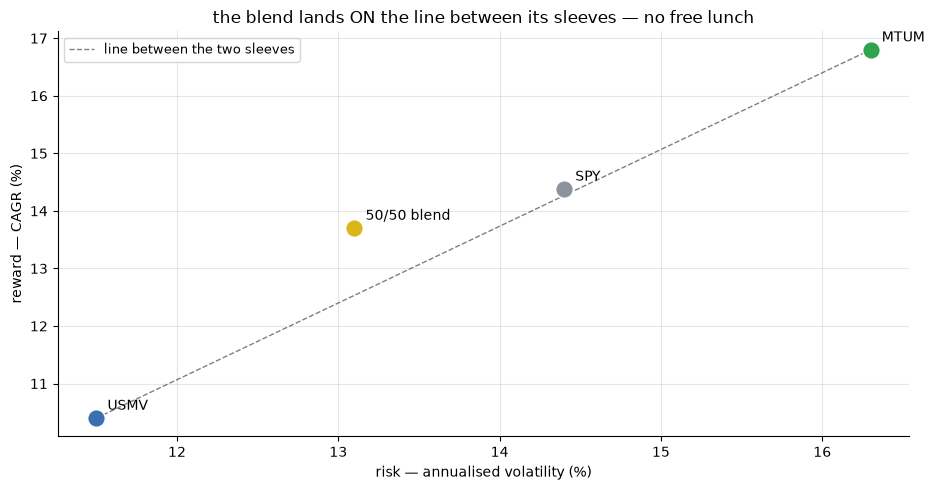

blend Sharpe 0.924  sits between USMV 0.775 and MTUM 0.941


In [2]:
fig, ax = plt.subplots()
pts = {'MTUM': (R['strat']['MTUM']['vol'], R['strat']['MTUM']['cagr'], GREEN),
       'USMV': (R['strat']['USMV']['vol'], R['strat']['USMV']['cagr'], BLUE),
       '50/50 blend': (R['strat']['BLEND']['vol'], R['strat']['BLEND']['cagr'], AMBER),
       'SPY': (R['strat']['SPY']['vol'], R['strat']['SPY']['cagr'], GREY)}
# the straight line between the two sleeves
mx, my = pts['MTUM'][0], pts['MTUM'][1]
ux, uy = pts['USMV'][0], pts['USMV'][1]
ax.plot([ux, mx], [uy, my], '--', color='k', lw=1, alpha=.5, label='line between the two sleeves')
for name,(x,y,c) in pts.items():
    ax.scatter([x],[y], s=160, color=c, zorder=3, edgecolor='white')
    ax.annotate(name, (x,y), textcoords='offset points', xytext=(8,6), fontsize=10)
ax.set_xlabel('risk — annualised volatility (%)'); ax.set_ylabel('reward — CAGR (%)')
ax.set_title('the blend lands ON the line between its sleeves — no free lunch')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print(f"blend Sharpe {R['strat']['BLEND']['sh']:.3f}  sits between USMV "
      f"{R['strat']['USMV']['sh']:.3f} and MTUM {R['strat']['MTUM']['sh']:.3f}")


The amber blend dot sits **right on the dashed line** between momentum and min-vol. That is the whole result in one image: mixing the two just **slides you down the line** toward less risk and less return. There is no bulge above the line — no diversification bonus lifting your risk-adjusted return. You picked a point on a risk dial; you did not find an edge.

## "Without the crashes" — sometimes true, and it failed when it mattered most

Here is the worst drop each strategy took in three sell-offs on the tape. Green shading means the blend helped; red means it didn't:

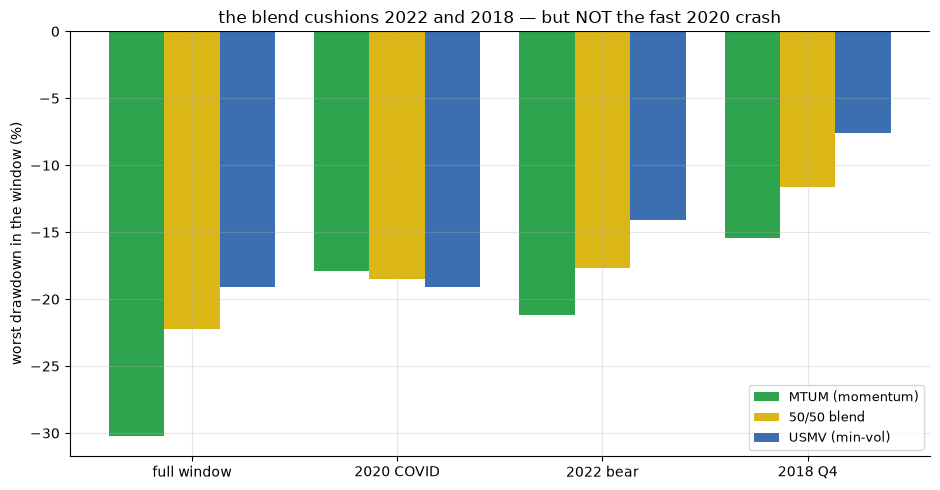

2020 COVID: MTUM -17.9%  blend -18.5%  USMV -19.1%  <- min-vol was the WORST of the three


In [3]:
labels = ['full window', '2020 COVID', '2022 bear', '2018 Q4']
keys = ['full', 'covid', 'bear22', 'q4_18']
mt = [R['crash'][k][0] for k in keys]
bl = [R['crash'][k][1] for k in keys]
uv = [R['crash'][k][2] for k in keys]
x = np.arange(len(labels)); w = 0.27
fig, ax = plt.subplots()
ax.bar(x-w, mt, w, color=GREEN, label='MTUM (momentum)')
ax.bar(x,   bl, w, color=AMBER, label='50/50 blend')
ax.bar(x+w, uv, w, color=BLUE, label='USMV (min-vol)')
ax.axhline(0, color='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('worst drawdown in the window (%)')
ax.set_title('the blend cushions 2022 and 2018 — but NOT the fast 2020 crash')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print(f"2020 COVID: MTUM {R['crash']['covid'][0]:.1f}%  blend {R['crash']['covid'][1]:.1f}%  "
      f"USMV {R['crash']['covid'][2]:.1f}%  <- min-vol was the WORST of the three")


Look at **2020 COVID** — the fastest crash on the whole tape, exactly the kind of violent reversal the overlay is supposed to defend against. Min-vol fell **-19.1%**, *more* than momentum's **-17.9%**, and dragged the blend to **-18.5%** — slightly **worse** than just holding momentum. The 'seat belt' unbuckled in the crash it was sold for. It *did* help in the slower 2022 grind and the 2018 wobble — so the protection is real but **unreliable**, not a rule you can lean on.

> 🧭 **And the big one is missing.** The canonical momentum crash was **2008-09** — but the MTUM ETF didn't exist until 2013, so it's **entirely outside** what we can test. The thesis's headline exhibit never makes it onto the tape.

## Every year, the blend is just the middle child

Calendar-year returns. By construction the blend is the average of its two sleeves — it never wins outright, never loses outright, and never surprises:

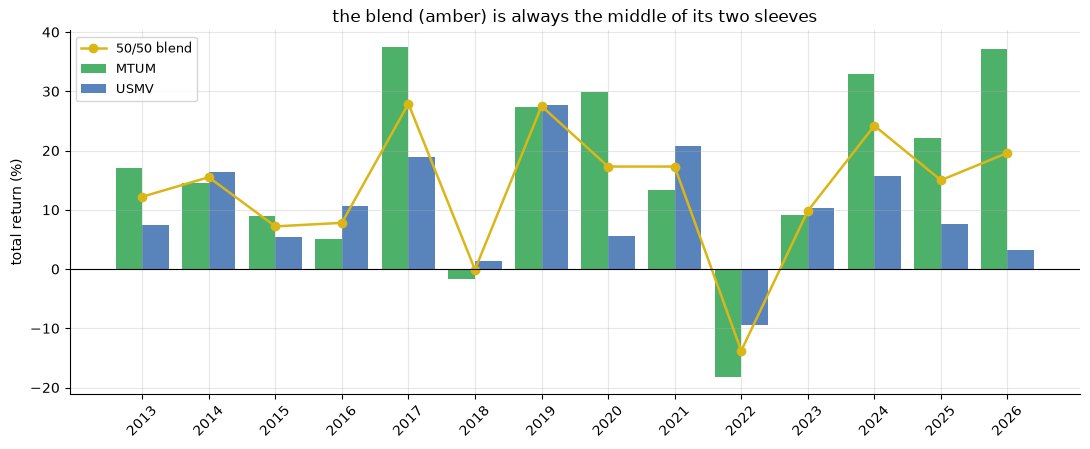

In [4]:
yrs = sorted(R['cal'])
mt = [R['cal'][y][0] for y in yrs]; uv = [R['cal'][y][1] for y in yrs]
bl = [R['cal'][y][2] for y in yrs]
x = np.arange(len(yrs)); w = 0.4
fig, ax = plt.subplots(figsize=(11,4.6))
ax.bar(x-w/2, mt, w, color=GREEN, alpha=.85, label='MTUM')
ax.bar(x+w/2, uv, w, color=BLUE, alpha=.85, label='USMV')
ax.plot(x, bl, 'o-', color=AMBER, lw=1.8, label='50/50 blend')
ax.axhline(0, color='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([str(y) for y in yrs], rotation=45)
ax.set_ylabel('total return (%)'); ax.set_title('the blend (amber) is always the middle of its two sleeves')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


## The verdict, in plain words

- **The calmer ride is real.** Lower volatility (13.1% vs 16.3%), a shallower worst-case fall on average (-22.2% vs -30.2%). If your goal is simply to shake less, the blend delivers.
- **The *edge* is not.** You paid for that calm with a matching cut in return (13.7% vs 16.8% CAGR). Risk-adjusted, it's a **wash** — Sharpe advantage -0.016, error bars across zero.
- **The crash hedge is unreliable.** Min-vol was *useless* in the 2020 crash, and the one crash the thesis is built on (2009) is off the tape entirely.
- **It's a risk dial, not a discovery.** Anyone wanting less momentum risk can simply hold less momentum and more cash — the min-vol sleeve adds nothing you couldn't get for free.

**Signal: Mixed (real risk cut, no Sharpe edge, unreliable hedge). Tradability: Mirage (a beta dial dressed as an edge).**

> 📓 Full statistics, the bootstrap CI, the era cut and the honest fine print: **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** · frozen numbers: [`docs/results.md`](../docs/results.md) (fingerprint `7d4dcacd42bd`).

*Research & education, not investment advice.*